# Biomarker S7 — Phân loại KL theo thứ tự (ordinal) trên bảng biomarker

**Input:** `s6_fcl/biomarker_table_v2.csv` (S6). Nếu chưa có, dùng `biomarker_table.csv` (S3, chỉ cột legacy).
**Output (thư mục mới):** `OAI_seg/knee_biomarkers_09_09/s7_ordinal/` — metric theo fold, dự đoán out-of-fold, hình, config.

**Câu hỏi notebook trả lời:** xử lý KL như **thứ tự** (KL0 < … < KL4) có tốt hơn 5 lớp rời rạc (S4) không, và
head ordinal của slide *Biomarker-guided ordinal multi-task* hành xử thế nào trên feature bảng.

**Cohort.** Manifest giữ 1325 dòng, gồm 1229 ca dùng cho S3 tới S7 và 96 ca OAIZIB-CM đã dành riêng
làm external validation. Cell cấu hình **tách 96 ca đó ra** và ghi danh sách vào
`external_validation_cases.csv`. Mọi con số dưới đây là trên 1229 ca, khớp cỡ mẫu của báo cáo.

**Thiết kế đánh giá (giống nhau cho mọi model):**
- `StratifiedGroupKFold` 5 fold **theo subject**, lặp 3 seed ⇒ 15 fold; cùng fold cho mọi model / feature set.
- Impute median **fit trên train** của từng fold.
- Metric chính **QWK** (quadratic-weighted kappa, chuẩn cho KL grading), kèm MAE và accuracy. Báo cả per-fold (mean ± sd)
  và trên dự đoán out-of-fold gộp theo seed (ổn định hơn khi lớp hiếm).

**Năm model** (định nghĩa trong `bsc/ordinal.py`, có test):

| | Model | Xử lý thứ tự | Giải mã |
|---|---|---|---|
| A | XGB softmax (S4) | không | argmax |
| A2 | MLP softmax, **cùng thân với D/E** | không | argmax head softmax |
| B | XGB Frank & Hall: 4 bộ nhị phân P(KL>k) | có | đếm p_k > 0.5 (sau cummin) |
| C | XGB hồi quy KL + điểm cắt tối ưu QWK | có | digitize |
| D | MLP loss ngưỡng + L_mono | có | đếm p_k > 0.5 |
| E | MLP, **đủ 4 thành phần loss của slide**: ngưỡng + L_mono + softmax CE + OA BCE | có | đếm p_k > 0.5 (so với head softmax) |

**D và E mượn HÀM MẤT MÁT của slide, không phải kiến trúc của slide.** Slide mô tả một mạng học
đầu cuối từ ảnh: encoder dùng chung, head phân đoạn, head biomarker, rồi module lâm sàng ghép ba
nguồn. S7 chỉ lấy phần loss ở trang 9–11 và đặt lên bảng biomarker đã tính sẵn. Chữ *MLP* không có
trong slide; hai lớp ẩn 64/32 là lựa chọn cho hàm φ, slide không chỉ định.

| Slide | Trong S7 |
|---|---|
| Encoder dùng chung trên X_MRI | không có, đầu vào là bảng số |
| Segmentation Head → M̂ | không có, mask do nnU-Net tạo trước ở S2 |
| Biomarker Head → b̂ | không có, biomarker tính bằng công thức ở S3/S6 |
| z = Fusion(GAP(F), Pool(F,M̂), φ(b̂)) | chỉ còn φ(b̂) |
| L_ord, L_mono, L_KL, L_OA | **có đủ bốn** |
| L_seg, L_bio | không có, không có head để huấn luyện |

Mục đích là phép thử rẻ trước khi bỏ hàng tuần GPU vào kiến trúc đầy đủ: nếu bộ máy ordinal không
thắng nổi softmax ngay trên bảng số thì khó tin nó làm nên khác biệt trong mạng đầu cuối. Chiều
ngược lại KHÔNG suy ra được.

**A2 là đối chứng, không phải model thứ sáu.** Chênh lệch `D − A` trộn hai thứ: đổi loss *và* đổi họ
mô hình, mạng nơ ron thay vì cây. A2 dùng **đúng thân MLP, đúng số epoch, đúng seed** như D và E, chỉ
đổi loss sang softmax. Nên `D − A2` mới là đóng góp riêng của loss ordinal, còn `A2 − A` là đóng góp
riêng của việc đổi sang mạng. Thiếu A2 thì không tách được hai thứ đó.

**Quy tắc giải mã được ghi rõ** vì slide chưa nói: `y = #{k : p_k > 0.5}`. Với ca KL3, p₁, p₂ "cao quá" không gây sai;
sai chỉ đến từ p₃ > 0.5 (lên KL4) hoặc p₂ < 0.5 (xuống KL2) — mục 5 đếm trực tiếp hai hướng này.
`L_OA` (KL ≥ 2) trùng sự kiện với ngưỡng p₁ = P(KL > 1); ở đây target OA tính từ **giá trị KL thật**, không từ chỉ số lớp
(cohort có thể thiếu KL0).

In [1]:
# ============================================================
# Moi truong: Drive + clone repo. MOI biomarker/model co MOT dinh nghia trong bsc/*.py,
# notebook chi goi - khong copy code vao day (quy tac "mot dinh nghia" cua CLAUDE.md).
# ============================================================
!pip install -q xgboost scikit-learn pandas matplotlib tqdm 2>/dev/null
from google.colab import drive
drive.mount("/content/drive")

REPO_URL, REPO_DIR = "https://github.com/AIVIETNAM-AIO-Tuan/bsCart-net.git", "/content/repo"
import os, sys
if not os.path.isdir(f"{REPO_DIR}/bsc"):
    !git clone -q $REPO_URL $REPO_DIR
!cd $REPO_DIR && git pull -q
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
for _m in [k for k in list(sys.modules) if k == "bsc" or k.startswith("bsc.")]:
    del sys.modules[_m]

import torch
from bsc import ordinal as ORD
from bsc.biomarkers import LEGACY_PREFIXES, SURFACE_PREFIXES
print("bsc.ordinal:", ORD.__file__, "| torch", torch.__version__)

Mounted at /content/drive
bsc.ordinal: /content/repo/bsc/ordinal.py | torch 2.11.0+cpu


## 0) Nạp bảng, chọn feature set, mã hóa nhãn

In [2]:
from pathlib import Path
import json, time
import numpy as np, pandas as pd
from tqdm.auto import tqdm

BIOM_DIR = Path("/content/drive/MyDrive/OAI_seg/knee_biomarkers_09_09")
V2_CSV = BIOM_DIR / "s6_fcl" / "biomarker_table_v2.csv"     # tu S6
S3_CSV = BIOM_DIR / "biomarker_table.csv"                    # fallback: bang S3 (chi legacy)
COMBINED_CSV = BIOM_DIR / "combined_features_table.csv"      # S5: legacy + TOAN BO radiomics tho
SELECTED_JSON = BIOM_DIR / "model_kl_classifier" / "selected_radiomics_features.json"
OUT_DIR = BIOM_DIR / "s7_ordinal"
OUT_DIR.mkdir(parents=True, exist_ok=True)
assert str(OUT_DIR).startswith("/content/drive/"), "Drive-first"

SRC = V2_CSV if V2_CSV.exists() else S3_CSV
assert SRC.exists(), f"khong thay {V2_CSV} lan {S3_CSV} - sua BIOM_DIR cho khop Drive cua ban"
df_all = pd.read_csv(SRC).drop_duplicates("case_id").reset_index(drop=True)
df_all = df_all.dropna(subset=["KL", "subject"]).copy()
df_all["KL"] = df_all["KL"].astype(int)

# ==== TACH 96 ca EXTERNAL VALIDATION ra khoi train/test ================================
# cohort_manifest.csv giu ca 1325 dong: 1229 ca dung cho S3-S7, cong 96 ca OAIZIB-CM da
# danh rieng lam external validation (source_dataset = reserved_external_validation_*,
# va cot oaizib_split). Neu KHONG loc, 96 ca do lot vao buoc impute + chon dac trung =>
# hong dung cai phep kiem ma viec tach sinh ra de phuc vu.
#
# Nhan split luon lay LAI TU MANIFEST, khong tin cot trong bang dac trung: bang S3 co the
# duoc sinh TRUOC khi phep tach ton tai, luc do source_dataset trong do la ban cu.
MANIFEST = BIOM_DIR / "cohort_manifest.csv"
SPLIT_COLS = ["source_dataset", "oaizib_split"]
EXT_PREFIX = "reserved_external_validation"

man = pd.read_csv(MANIFEST).drop_duplicates("case_id")
have = [c for c in SPLIT_COLS if c in man.columns]
assert have, f"{MANIFEST.name} khong co cot nao trong {SPLIT_COLS} - khong tach duoc external"
df_all = df_all.drop(columns=[c for c in have if c in df_all.columns], errors="ignore")
df_all = df_all.merge(man[["case_id"] + have], on="case_id", how="left")

is_ext = pd.Series(False, index=df_all.index)
if "source_dataset" in have:
    is_ext |= df_all["source_dataset"].astype(str).str.startswith(EXT_PREFIX)
if "oaizib_split" in have:
    is_ext |= df_all["oaizib_split"].astype(str).str.contains("ext", case=False, na=False)

df_ext = df_all[is_ext].reset_index(drop=True)
df = df_all[~is_ext].reset_index(drop=True)
assert not (set(df["case_id"]) & set(df_ext["case_id"])), "co ca nam ca hai ben"
df_ext[["case_id"]].to_csv(OUT_DIR / "external_validation_cases.csv", index=False)
print(f"tong {len(df_all)} | train/test {len(df)} | external giu rieng {len(df_ext)}")
if len(df_ext) == 0 and len(df_all) > 1250:
    print("CANH BAO: bang co >1250 dong nhung khong tach duoc ca external nao "
          "-> bang dac trung/manifest khong khop, kiem lai truoc khi tin ket qua.")
elif len(df_ext) == 0:
    print("(bang dac trung von chi chua tap train/test, khong co ca external de tach - binh thuong)")
# ======================================================================================

print("nguon:", SRC.name, "| ca:", len(df), "| subject:", df["subject"].nunique())

legacy_cols = [c for c in df.columns if c.startswith(LEGACY_PREFIXES)]
surface_cols = [c for c in df.columns if c.startswith(SURFACE_PREFIXES)]
FEATURE_SETS = {"legacy_s3": legacy_cols}
if surface_cols:
    FEATURE_SETS["s6_surface_only"] = surface_cols
    FEATURE_SETS["s6_all"] = legacy_cols + surface_cols

# ==== Radiomics cua S5: de so DUOC voi con so 0,762 trong bao cao ======================
# Bang legacy 15 cot khong the so voi 0,762 - con so do dung 93 cot CO radiomics. Nap
# `combined_features_table.csv` (legacy + toan bo radiomics tho) de dung chung cau hinh.
#
# HAI feature set, co y tach doi:
#   s5_radiomics        - radiomics THO, chon dac trung lai TRONG TUNG FOLD (trung thuc)
#   s5_fixed_KE_THUA    - dung y nguyen danh sach S5 da chon san. So sanh 1:1 voi bao cao,
#                         NHUNG buoc chon do da fit tren mot lan chia khac, nen cac ca dang
#                         nam trong fold test cua ta da tung duoc nhin thay => con so nay
#                         LAC QUAN, chi de doi chieu, khong dung lam ket luan.
RAD_PREFIX = "rad_"
if COMBINED_CSV.exists():
    comb = pd.read_csv(COMBINED_CSV).drop_duplicates("case_id")
    rad_cols = [c for c in comb.columns if c.startswith(RAD_PREFIX)]
    df = df.merge(comb[["case_id"] + rad_cols], on="case_id", how="left")
    print(f"nap radiomics: {len(rad_cols)} cot tho tu {COMBINED_CSV.name}")
    FEATURE_SETS["s5_radiomics"] = legacy_cols + rad_cols
    if surface_cols:
        FEATURE_SETS["s6_all_plus_radiomics"] = legacy_cols + surface_cols + rad_cols
    if SELECTED_JSON.exists():
        sel_s5 = [c for c in json.load(open(SELECTED_JSON)) if c in df.columns]
        if sel_s5:
            FEATURE_SETS["s5_fixed_KE_THUA"] = sel_s5
            print(f"nap danh sach S5 da chon san: {len(sel_s5)} cot (ke thua, con so se LAC QUAN)")
    else:
        print(f"khong thay {SELECTED_JSON.name} -> bo qua feature set ke thua")
else:
    print(f"khong thay {COMBINED_CSV.name} -> chi chay tren feature set hinh hoc")

print("so feature:", {k: len(v) for k, v in FEATURE_SETS.items()})

# Nhan: chi so lop 0..K-1 theo cac muc KL CO MAT (cohort co the thieu KL0)
CLASSES = sorted(df["KL"].unique().tolist())
K = len(CLASSES)
cls_to_idx = {c: i for i, c in enumerate(CLASSES)}
y_idx = df["KL"].map(cls_to_idx).to_numpy(np.int64)
groups = df["subject"].astype(str).to_numpy()
oa_target = (df["KL"] >= 2).to_numpy(np.float32)      # OA status = KL>=2 (slide 5/11), tu gia tri KL THAT
print("KL classes:", CLASSES, "| n moi lop:", np.bincount(y_idx, minlength=K).tolist())
print("nguong t_k = 1(KL > k):", [f"KL>{c}" for c in CLASSES[:-1]])

tong 1229 | train/test 1229 | external giu rieng 0
(bang dac trung von chi chua tap train/test, khong co ca external de tach - binh thuong)
nguon: biomarker_table_v2.csv | ca: 1229 | subject: 1215


/tmp/ipykernel_1301/621090270.py:78: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  comb = pd.read_csv(COMBINED_CSV).drop_duplicates("case_id")


nap radiomics: 856 cot tho tu combined_features_table.csv
nap danh sach S5 da chon san: 82 cot (ke thua, con so se LAC QUAN)
so feature: {'legacy_s3': 15, 's6_surface_only': 55, 's6_all': 70, 's5_radiomics': 871, 's6_all_plus_radiomics': 926, 's5_fixed_KE_THUA': 82}
KL classes: [0, 1, 2, 3, 4] | n moi lop: [284, 233, 295, 311, 106]
nguong t_k = 1(KL > k): ['KL>0', 'KL>1', 'KL>2', 'KL>3']


## 1) CV theo subject — cùng fold cho mọi model

In [3]:
from sklearn.model_selection import StratifiedGroupKFold
N_SPLITS, SEEDS = 5, [0, 1, 2]
FOLDS = []
for s in SEEDS:
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=s)
    for f, (tr, te) in enumerate(sgkf.split(df, y_idx, groups)):
        assert not (set(groups[tr]) & set(groups[te])), "ro ri subject giua train/test"
        FOLDS.append((s, f, tr, te))
print(len(FOLDS), "fold | kich thuoc test:", sorted({len(te) for *_, te in FOLDS}))

15 fold | kich thuoc test: [243, 244, 245, 246, 247, 248]


## 2) Năm model — cùng dữ liệu, khác cách xử lý thứ tự

Siêu tham số XGB giữ nguyên S4 để so sánh công bằng. MLP: 2 lớp ẩn 64/32, full-batch Adam 400 epoch, không tinh chỉnh.
Mục tiêu là so *cách xử lý thứ tự*, không phải săn siêu tham số.

In [4]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold, cross_val_predict

XGB_KW = dict(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
              colsample_bytree=0.8, random_state=42, n_jobs=2)   # = S4
MLP_EPOCHS = 400

def m_softmax(Xtr, ytr, Xte, **_):
    clf = XGBClassifier(objective="multi:softprob", num_class=K, eval_metric="mlogloss", **XGB_KW)
    clf.fit(Xtr, ytr)
    p = clf.predict_proba(Xte)
    return dict(y_pred=p.argmax(1), p_cls=p)

def m_frankhall(Xtr, ytr, Xte, **_):
    fh = ORD.FrankHall(lambda: XGBClassifier(objective="binary:logistic", eval_metric="logloss", **XGB_KW))
    fh.fit(Xtr, ytr, K)
    p = fh.predict_proba_thresholds(Xte)
    # y_alt = quy tac giai ma cua bao cao 13/9 (hieu so lien tiep roi argmax), de so truc tiep
    return dict(y_pred=ORD.decode_count(p), p_thr=p, y_alt=ORD.decode_cumdiff(p))

def m_reg_cutpoints(Xtr, ytr, Xte, gtr=None, **_):
    reg = XGBRegressor(objective="reg:squarederror", **XGB_KW)
    inner = cross_val_predict(reg, Xtr, ytr, groups=gtr, cv=GroupKFold(n_splits=4))   # diem HONEST cho diem cat
    cuts = ORD.fit_cutpoints(inner, ytr, K)
    reg.fit(Xtr, ytr)
    return dict(y_pred=ORD.apply_cutpoints(reg.predict(Xte), cuts), cuts=cuts)

def m_mlp_softmax(Xtr, ytr, Xte, **_):
    """DOI CHUNG cho D: cung than MLP, cung epoch, cung seed, chi doi loss sang softmax CE.

    Thieu no thi chenh lech D tru A tron HAI thu: doi loss (nguong vs softmax) VA doi ho mo
    hinh (mang vs cay). Co no thi D tru A2 la dong gop RIENG cua loss ordinal.
    Giai ma bang argmax head softmax; head nguong khong nhan gradient nen p_thr vo nghia
    (do duoc: det quanh 0.5) => KHONG tra p_thr de muc chan doan bo qua model nay.
    """
    model, info = ORD.train_ordinal_mlp(Xtr, ytr, K, lambdas=ORD.SOFTMAX_ONLY_LAMBDAS,
                                        epochs=MLP_EPOCHS, seed=0)
    out = ORD.predict_ordinal_mlp(model, info, Xte)
    return dict(y_pred=out["y_softmax"], p_cls=out["p_cls"])


def m_mlp_ordinal(Xtr, ytr, Xte, **_):
    model, info = ORD.train_ordinal_mlp(Xtr, ytr, K, lambdas=ORD.ORDINAL_ONLY_LAMBDAS, epochs=MLP_EPOCHS, seed=0)
    out = ORD.predict_ordinal_mlp(model, info, Xte)
    return dict(y_pred=out["y_count"], p_thr=out["p_thr"], y_alt=out["y_cumdiff"])

def m_mlp_slide(Xtr, ytr, Xte, oa_tr=None, **_):
    model, info = ORD.train_ordinal_mlp(Xtr, ytr, K, oa_target=oa_tr, lambdas=ORD.SLIDE_LAMBDAS,
                                        epochs=MLP_EPOCHS, seed=0)
    out = ORD.predict_ordinal_mlp(model, info, Xte)
    return dict(y_pred=out["y_count"], p_thr=out["p_thr"], y_alt=out["y_softmax"], p_cls=out["p_cls"])

MODELS = {
    "A_xgb_softmax":         m_softmax,        # nominal (S4)
    "A2_mlp_softmax":        m_mlp_softmax,    # nominal, CUNG than MLP voi D/E -> doi chung
    "B_xgb_frankhall":       m_frankhall,      # ordinal: K-1 nhi phan, giai ma dem
    "C_xgb_reg_cutpoints":   m_reg_cutpoints,  # ordinal: hoi quy + diem cat QWK
    "D_mlp_ordinal_only":    m_mlp_ordinal,    # ordinal: loss nguong + L_mono
    "E_mlp_slide_multitask": m_mlp_slide,      # dung loss slide: nguong + L_mono + softmax + OA
}

## 3) Chạy CV — gom dự đoán out-of-fold (~10–15 phút CPU)

In [5]:
SELECT_ABOVE = 120     # tren nguong nay thi chon dac trung lai trong tung fold

records, OOF, n_sel = [], {}, {}
t_start = time.time()
for fs_name, cols in FEATURE_SETS.items():
    X_all = df[cols].to_numpy(np.float32)
    for (seed, f, tr, te) in tqdm(FOLDS, desc=fs_name):
        imp = SimpleImputer(strategy="median").fit(X_all[tr])       # impute CHI tu train
        Xtr, Xte = imp.transform(X_all[tr]), imp.transform(X_all[te])
        if len(cols) > SELECT_ABOVE:
            # fit CHI tren train cua fold nay - day la diem khac voi danh sach ke thua cua S5
            keep = ORD.select_features(Xtr, y_idx[tr], seed=seed)
            Xtr, Xte = Xtr[:, keep], Xte[:, keep]
            n_sel.setdefault(fs_name, []).append(len(keep))
        for m_name, fn in MODELS.items():
            r = fn(Xtr, y_idx[tr], Xte, gtr=groups[tr], oa_tr=oa_target[tr])
            key = (fs_name, m_name, seed)
            st = OOF.setdefault(key, dict(y_pred=np.full(len(df), -1), y_alt=np.full(len(df), -1),
                                          p_thr=np.full((len(df), K - 1), np.nan)))
            yp = np.asarray(r["y_pred"], np.int64)
            st["y_pred"][te] = yp
            if r.get("p_thr") is not None:
                st["p_thr"][te] = r["p_thr"]
            if r.get("y_alt") is not None:
                st["y_alt"][te] = r["y_alt"]
            records.append(dict(feature_set=fs_name, model=m_name, seed=seed, fold=f, n_test=len(te),
                                qwk=ORD.qwk(y_idx[te], yp, K), acc=float((yp == y_idx[te]).mean()),
                                mae=ORD.mae(y_idx[te], yp)))
res = pd.DataFrame(records)
res.to_csv(OUT_DIR / "cv_fold_metrics.csv", index=False)
if n_sel:
    print("so cot giu lai sau chon trong fold:",
          {k: f"{np.mean(v):.0f} +- {np.std(v):.0f}" for k, v in n_sel.items()})
print(f"xong {len(res)} (feature_set, model, fold) trong {(time.time() - t_start) / 60:.1f} phut")

legacy_s3:   0%|          | 0/15 [00:00<?, ?it/s]

s6_surface_only:   0%|          | 0/15 [00:00<?, ?it/s]

s6_all:   0%|          | 0/15 [00:00<?, ?it/s]

s5_radiomics:   0%|          | 0/15 [00:00<?, ?it/s]

s6_all_plus_radiomics:   0%|          | 0/15 [00:00<?, ?it/s]

s5_fixed_KE_THUA:   0%|          | 0/15 [00:00<?, ?it/s]

so cot giu lai sau chon trong fold: {'s5_radiomics': '104 +- 20', 's6_all_plus_radiomics': '103 +- 16'}
xong 540 (feature_set, model, fold) trong 41.3 phut


## 4) Kết quả — nominal (A) vs ordinal (B–E), theo feature set

Đọc: (1) B–E có hơn A về **QWK/MAE** không (ordinal thường được MAE, accuracy có thể không đổi); (2) thêm cột S6 có giúp
so với legacy không. Sd qua fold thường 0.05–0.1 với N vài trăm ⇒ chênh dưới mức đó chưa kết luận được.

**Đối chiếu với báo cáo 13/9.** Báo cáo dùng một lần chia `GroupShuffleSplit` với 246 ca test; ở đây là
out-of-fold trên cả 1229 ca qua 15 fold, tức bài toán khó hơn, nên đừng trông đợi hai con số bằng nhau.
Feature set nào so với con số nào:

| Feature set | So được với | Ghi chú |
|---|---|---|
| `legacy_s3` | S4 gốc, κ = 0,532 | 15 biến hình học, không radiomics |
| `s5_radiomics` | S5 / nominal 93 cột, κ ≈ 0,758 | chọn đặc trưng **lại trong từng fold** |
| `s5_fixed_KE_THUA` | Frank-Hall, κ = 0,762 | dùng lại danh sách S5 đã chọn ⇒ **lạc quan**, chỉ để đối chiếu |
| `s6_*` | chưa có trong báo cáo | cần bảng v2 từ S6 |

per-fold (mean ± sd qua 15 fold):


qwk           acc           mae       
                                              mean    std   mean    std   mean    std
feature_set           model                                                          
legacy_s3             A2_mlp_softmax         0.621  0.049  0.450  0.026  0.774  0.060
                      A_xgb_softmax          0.553  0.055  0.412  0.029  0.840  0.057
                      B_xgb_frankhall        0.579  0.042  0.398  0.028  0.777  0.043
                      C_xgb_reg_cutpoints    0.599  0.042  0.336  0.030  0.874  0.054
                      D_mlp_ordinal_only     0.638  0.039  0.414  0.028  0.725  0.039
                      E_mlp_slide_multitask  0.643  0.046  0.424  0.023  0.716  0.039
s5_fixed_KE_THUA      A2_mlp_softmax         0.737  0.035  0.514  0.025  0.606  0.042
                      A_xgb_softmax          0.738  0.023  0.519  0.024  0.599  0.027
                      B_xgb_frankhall        0.768  0.026  0.524  0.028  0.551  0.031
                      C_xgb_reg_cutpoints    0.776  0.024  0.472  0.029  0.611  0.036
                      D_mlp_ordinal_only     0.763  0.027  0.524  0.027  0.563  0.037
                      E_mlp_slide_multitask  0.761  0.026  0.537  0.022  0.557  0.031
s5_radiomics          A2_mlp_softmax         0.742  0.035  0.514  0.022  0.599  0.032
                      A_xgb_softmax          0.737  0.033  0.519  0.025  0.599  0.035
                      B_xgb_frankhall        0.762  0.039  0.517  0.033  0.555  0.051
                      C_xgb_reg_cutpoints    0.775  0.023  0.481  0.030  0.604  0.037
                      D_mlp_ordinal_only     0.769  0.030  0.538  0.024  0.549  0.037
                      E_mlp_slide_multitask  0.763  0.034  0.539  0.024  0.554  0.037
s6_all                A2_mlp_softmax         0.668  0.026  0.473  0.030  0.708  0.040
                      A_xgb_softmax          0.634  0.066  0.459  0.025  0.744  0.070
                      B_xgb_frankhall        0.662  0.045  0.447  0.033  0.686  0.051
                      C_xgb_reg_cutpoints    0.691  0.050  0.408  0.044  0.739  0.066
                      D_mlp_ordinal_only     0.716  0.028  0.486  0.036  0.633  0.041
                      E_mlp_slide_multitask  0.704  0.033  0.487  0.038  0.643  0.048
s6_all_plus_radiomics A2_mlp_softmax         0.737  0.034  0.513  0.022  0.604  0.033
                      A_xgb_softmax          0.749  0.029  0.530  0.023  0.580  0.036
                      B_xgb_frankhall        0.775  0.030  0.534  0.021  0.533  0.036
                      C_xgb_reg_cutpoints    0.771  0.025  0.481  0.035  0.612  0.039
                      D_mlp_ordinal_only     0.773  0.024  0.536  0.025  0.547  0.035
                      E_mlp_slide_multitask  0.764  0.025  0.533  0.018  0.558  0.035
s6_surface_only       A2_mlp_softmax         0.623  0.042  0.432  0.030  0.784  0.055
                      A_xgb_softmax          0.561  0.059  0.415  0.023  0.834  0.054
                      B_xgb_frankhall        0.597  0.055  0.406  0.028  0.757  0.052
                      C_xgb_reg_cutpoints    0.629  0.055  0.381  0.029  0.801  0.061
                      D_mlp_ordinal_only     0.665  0.038  0.423  0.032  0.708  0.040
                      E_mlp_slide_multitask  0.658  0.042  0.426  0.037  0.710  0.046

out-of-fold gop (mean ± sd qua 3 seed):


qwk           mae           acc       
                                              mean    std   mean    std   mean    std
feature_set           model                                                          
legacy_s3             A2_mlp_softmax         0.622  0.008  0.774  0.014  0.450  0.009
                      A_xgb_softmax          0.554  0.014  0.840  0.014  0.412  0.008
                      B_xgb_frankhall        0.580  0.003  0.777  0.009  0.398  0.014
                      C_xgb_reg_cutpoints    0.599  0.005  0.874  0.016  0.336  0.015
                      D_mlp_ordinal_only     0.640  0.005  0.725  0.007  0.414  0.007
                      E_mlp_slide_multitask  0.644  0.009  0.716  0.008  0.424  0.005
s5_fixed_KE_THUA      A2_mlp_softmax         0.738  0.003  0.606  0.005  0.514  0.004
                      A_xgb_softmax          0.739  0.005  0.599  0.013  0.519  0.015
                      B_xgb_frankhall        0.769  0.004  0.551  0.009  0.524  0.010
                      C_xgb_reg_cutpoints    0.777  0.010  0.611  0.021  0.472  0.013
                      D_mlp_ordinal_only     0.764  0.005  0.563  0.013  0.523  0.013
                      E_mlp_slide_multitask  0.762  0.003  0.557  0.006  0.537  0.008
s5_radiomics          A2_mlp_softmax         0.743  0.006  0.599  0.002  0.514  0.003
                      A_xgb_softmax          0.738  0.015  0.599  0.025  0.519  0.017
                      B_xgb_frankhall        0.763  0.002  0.555  0.008  0.517  0.009
                      C_xgb_reg_cutpoints    0.775  0.003  0.604  0.008  0.481  0.011
                      D_mlp_ordinal_only     0.770  0.013  0.549  0.018  0.538  0.010
                      E_mlp_slide_multitask  0.764  0.003  0.554  0.009  0.539  0.008
s6_all                A2_mlp_softmax         0.669  0.003  0.708  0.005  0.473  0.004
                      A_xgb_softmax          0.636  0.006  0.744  0.008  0.459  0.004
                      B_xgb_frankhall        0.664  0.006  0.686  0.007  0.447  0.008
                      C_xgb_reg_cutpoints    0.693  0.004  0.739  0.014  0.408  0.012
                      D_mlp_ordinal_only     0.717  0.009  0.633  0.013  0.486  0.006
                      E_mlp_slide_multitask  0.706  0.011  0.643  0.020  0.487  0.017
s6_all_plus_radiomics A2_mlp_softmax         0.739  0.004  0.604  0.008  0.513  0.005
                      A_xgb_softmax          0.750  0.006  0.580  0.007  0.530  0.001
                      B_xgb_frankhall        0.776  0.005  0.533  0.004  0.534  0.004
                      C_xgb_reg_cutpoints    0.772  0.003  0.612  0.005  0.481  0.003
                      D_mlp_ordinal_only     0.774  0.002  0.547  0.003  0.536  0.004
                      E_mlp_slide_multitask  0.764  0.008  0.558  0.011  0.533  0.007
s6_surface_only       A2_mlp_softmax         0.624  0.009  0.784  0.017  0.432  0.013
                      A_xgb_softmax          0.564  0.007  0.834  0.010  0.415  0.009
                      B_xgb_frankhall        0.600  0.015  0.757  0.019  0.406  0.013
                      C_xgb_reg_cutpoints    0.631  0.008  0.801  0.018  0.381  0.015
                      D_mlp_ordinal_only     0.666  0.006  0.708  0.007  0.423  0.005
                      E_mlp_slide_multitask  0.660  0.006  0.710  0.003  0.426  0.002

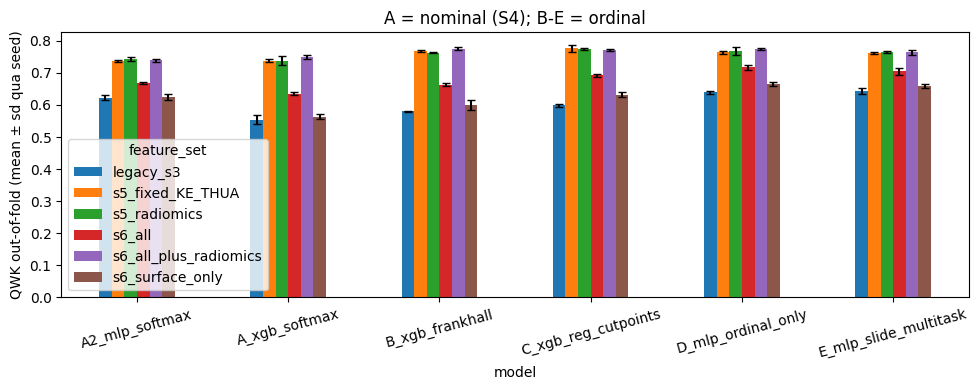

In [6]:
import matplotlib.pyplot as plt
pd.set_option("display.width", 180)
fold_summary = res.groupby(["feature_set", "model"])[["qwk", "acc", "mae"]].agg(["mean", "std"]).round(3)
print("per-fold (mean ± sd qua 15 fold):")
display(fold_summary)

pooled = []
for (fs, m, s), st in OOF.items():
    ok = st["y_pred"] >= 0
    pooled.append(dict(feature_set=fs, model=m, seed=s, qwk=ORD.qwk(y_idx[ok], st["y_pred"][ok], K),
                       mae=ORD.mae(y_idx[ok], st["y_pred"][ok]), acc=float((st["y_pred"][ok] == y_idx[ok]).mean())))
pooled = pd.DataFrame(pooled)
pooled_summary = pooled.groupby(["feature_set", "model"])[["qwk", "mae", "acc"]].agg(["mean", "std"]).round(3)
print("out-of-fold gop (mean ± sd qua 3 seed):")
display(pooled_summary)

fig, ax = plt.subplots(figsize=(10, 4))
piv = pooled.groupby(["model", "feature_set"])["qwk"].mean().unstack("feature_set")
piv_sd = pooled.groupby(["model", "feature_set"])["qwk"].std().unstack("feature_set")
piv.plot.bar(ax=ax, yerr=piv_sd, capsize=3, rot=15)
ax.set_ylabel("QWK out-of-fold (mean ± sd qua seed)")
ax.set_title("A = nominal (S4); B-E = ordinal")
plt.tight_layout(); plt.savefig(OUT_DIR / "qwk_by_model.png", dpi=130); plt.show()

## 5) Chẩn đoán head ordinal — bảng p_k theo KL thật, hướng sai, khớp giữa các cách giải mã

- **Bảng p_k trung bình theo KL thật:** lý tưởng là bậc thang (hàng KL3: cao, cao, cao, thấp). Ngưỡng cuối
  P(KL>3) thường hiệu chỉnh kém nhất vì KL4 hiếm.
- **Hướng sai ở lớp kề cuối (KL3):** đếm trực tiếp "sai LÊN do p₃ > 0.5" và "sai XUỐNG do p₂ ≤ 0.5".
- **Khớp giải mã:** E có head softmax và head ordinal cùng dự đoán KL; tỉ lệ bất đồng là mức "3 head mâu thuẫn" mà slide chưa xử lý.

In [7]:
from sklearn.metrics import confusion_matrix
# Chan doan phai chay tren bo dac trung GIAU NHAT dang co, khong phai bo dau tien trong dict.
# Ban truoc lay list(FEATURE_SETS)[0] = legacy_s3, tuc muc 5 va 6 deu chay tren 15 cot trong
# khi ket qua dang duoc doc tren bo co radiomics => chan doan khong khop voi so duoc bao cao.
FS_PRIORITY = ["s6_all_plus_radiomics", "s6_all", "s5_radiomics", "s5_fixed_KE_THUA",
               "s6_surface_only", "legacy_s3"]
FS_SHOW = next((k for k in FS_PRIORITY if k in FEATURE_SETS), list(FEATURE_SETS)[0])
print(f"chan doan tren feature set: {FS_SHOW} ({len(FEATURE_SETS[FS_SHOW])} cot)")
SEED_SHOW = SEEDS[0]
thr_names = [f"P(KL>{c})" for c in CLASSES[:-1]]
for m_name in ["B_xgb_frankhall", "D_mlp_ordinal_only", "E_mlp_slide_multitask"]:
    st = OOF[(FS_SHOW, m_name, SEED_SHOW)]
    ok = ~np.isnan(st["p_thr"]).any(axis=1)
    p, y, yp = st["p_thr"][ok], y_idx[ok], st["y_pred"][ok]
    print(f"\n==== {m_name} | {FS_SHOW} | seed {SEED_SHOW} | n={int(ok.sum())}")
    print("p_k trung binh theo KL that (ly tuong: bac thang 1..1,0..0):")
    display(pd.DataFrame(ORD.mean_p_by_class(p, y, K), index=[f"KL{c}" for c in CLASSES], columns=thr_names).round(2))
    print("AUC tung nguong:", dict(zip(thr_names, np.round(ORD.threshold_auc(p, ORD.to_thresholds(y, K)), 3))))
    print(f"hang p khong don dieu: {ORD.monotonic_violation_rate(p):.3f}")
    print(f"doan CAO hon that: {(yp > y).mean():.3f} | THAP hon that: {(yp < y).mean():.3f}")
    if K >= 3:
        c3 = K - 2                                   # lop ke cuoi (= KL3 neu du KL0..4)
        m3 = y == c3
        if m3.any():
            over = (p[m3, c3] > 0.5).mean()          # p_{c3} > 0.5  -> len lop cuoi
            under = (p[m3, c3 - 1] <= 0.5).mean()    # p_{c3-1} <= 0.5 -> xuong lop duoi
            print(f"KL{CLASSES[c3]} (n={int(m3.sum())}): sai LEN do {thr_names[c3]}>0.5: {over:.3f} | "
                  f"sai XUONG do {thr_names[c3 - 1]}<=0.5: {under:.3f}")
    alt = st["y_alt"][ok]
    if (alt >= 0).all():
        name = "head softmax" if "slide" in m_name else "cumdiff"
        print(f"khop giai ma dem vs {name}: {(alt == yp).mean():.3f}")
    print("confusion (hang = that, cot = doan; thu tu", CLASSES, ")")
    print(confusion_matrix(y, yp, labels=list(range(K))))

chan doan tren feature set: s6_all_plus_radiomics (926 cot)

==== B_xgb_frankhall | s6_all_plus_radiomics | seed 0 | n=1229
p_k trung binh theo KL that (ly tuong: bac thang 1..1,0..0):


,P(KL>0),P(KL>1),P(KL>2),P(KL>3)
KL0,0.49,0.19,0.03,0.00
KL1,0.73,0.36,0.06,0.00
KL2,0.90,0.66,0.22,0.01
KL3,0.97,0.91,0.67,0.08
KL4,1.00,0.99,0.94,0.46


AUC tung nguong: {'P(KL>0)': np.float64(0.872), 'P(KL>1)': np.float64(0.902), 'P(KL>2)': np.float64(0.934), 'P(KL>3)': np.float64(0.952)}
hang p khong don dieu: 0.000
doan CAO hon that: 0.227 | THAP hon that: 0.234
KL3 (n=311): sai LEN do P(KL>3)>0.5: 0.058 | sai XUONG do P(KL>2)<=0.5: 0.305
khop giai ma dem vs cumdiff: 0.948
confusion (hang = that, cot = doan; thu tu [0, 1, 2, 3, 4] )
[[152  98  31   3   0]
 [ 47 115  67   4   0]
 [ 17  75 145  56   2]
 [  2  18  75 198  18]
 [  0   0   2  52  52]]

==== D_mlp_ordinal_only | s6_all_plus_radiomics | seed 0 | n=1229
p_k trung binh theo KL that (ly tuong: bac thang 1..1,0..0):


,P(KL>0),P(KL>1),P(KL>2),P(KL>3)
KL0,0.47,0.17,0.01,0.00
KL1,0.72,0.37,0.05,0.00
KL2,0.91,0.69,0.23,0.01
KL3,0.98,0.94,0.74,0.12
KL4,1.00,0.99,0.96,0.57


AUC tung nguong: {'P(KL>0)': np.float64(0.871), 'P(KL>1)': np.float64(0.902), 'P(KL>2)': np.float64(0.931), 'P(KL>3)': np.float64(0.927)}
hang p khong don dieu: 0.049
doan CAO hon that: 0.245 | THAP hon that: 0.217
KL3 (n=311): sai LEN do P(KL>3)>0.5: 0.109 | sai XUONG do P(KL>2)<=0.5: 0.248
khop giai ma dem vs cumdiff: 0.991
confusion (hang = that, cot = doan; thu tu [0, 1, 2, 3, 4] )
[[160  81  42   1   0]
 [ 62  89  71  11   0]
 [ 21  64 149  60   1]
 [  3  17  57 200  34]
 [  0   1   4  38  63]]

==== E_mlp_slide_multitask | s6_all_plus_radiomics | seed 0 | n=1229
p_k trung binh theo KL that (ly tuong: bac thang 1..1,0..0):


,P(KL>0),P(KL>1),P(KL>2),P(KL>3)
KL0,0.47,0.17,0.02,0.00
KL1,0.74,0.39,0.06,0.00
KL2,0.90,0.70,0.22,0.01
KL3,0.98,0.93,0.75,0.12
KL4,1.00,0.99,0.95,0.56


AUC tung nguong: {'P(KL>0)': np.float64(0.872), 'P(KL>1)': np.float64(0.897), 'P(KL>2)': np.float64(0.929), 'P(KL>3)': np.float64(0.918)}
hang p khong don dieu: 0.166
doan CAO hon that: 0.251 | THAP hon that: 0.208
KL3 (n=311): sai LEN do P(KL>3)>0.5: 0.103 | sai XUONG do P(KL>2)<=0.5: 0.235
khop giai ma dem vs head softmax: 0.894
confusion (hang = that, cot = doan; thu tu [0, 1, 2, 3, 4] )
[[159  83  38   4   0]
 [ 51  91  80  11   0]
 [ 23  61 150  60   1]
 [  2  19  52 206  32]
 [  0   0   4  44  58]]


## 5b) Precision / Recall / F1 theo từng lớp — như Bảng 6 của báo cáo

Kappa và accuracy là một con số duy nhất, chúng không cho biết mô hình bỏ sót lớp nào. Báo cáo 13/9
gọi bảng recall theo lớp là *phát hiện quan trọng nhất*, nên S7 xuất bảng tương đương — khác ở chỗ
tính trên **toàn bộ cohort out-of-fold** thay vì 246 ca của một lần chia.

Đọc kèm cỡ mẫu. KL4 chỉ có 106 ca trong cả cohort nên recall của nó vẫn là con số nhiễu nhất, và
KL1 là lớp khó nhất qua mọi báo cáo.

In [8]:
from sklearn.metrics import precision_recall_fscore_support

rows = []
for (fs, m_name, s), st in OOF.items():
    if s != SEED_SHOW:
        continue
    ok = st["y_pred"] >= 0
    pr, rc, f1, sup = precision_recall_fscore_support(
        y_idx[ok], st["y_pred"][ok], labels=list(range(K)), zero_division=0)
    for k in range(K):
        rows.append(dict(feature_set=fs, model=m_name, KL=str(CLASSES[k]), n=int(sup[k]),
                         precision=pr[k], recall=rc[k], f1=f1[k]))
    rows.append(dict(feature_set=fs, model=m_name, KL="macro", n=int(sup.sum()),
                     precision=pr.mean(), recall=rc.mean(), f1=f1.mean()))

per_class = pd.DataFrame(rows)
per_class.to_csv(OUT_DIR / f"per_class_seed{SEED_SHOW}.csv", index=False)
print("da luu per_class_seed" + str(SEED_SHOW) + ".csv | feature set dang hien:", FS_SHOW)

sub = per_class[per_class.feature_set == FS_SHOW]
n_lop = sub[sub.model == sub.model.iloc[0]].set_index("KL")["n"].to_dict()
print("co mau moi lop:", {k: v for k, v in n_lop.items() if k != "macro"})

for metric in ["recall", "precision", "f1"]:
    print()
    print(metric.upper() + " theo lop (%), out-of-fold n=" + str(len(df)))
    display((sub.pivot(index="model", columns="KL", values=metric) * 100).round(1))


da luu per_class_seed0.csv | feature set dang hien: s6_all_plus_radiomics
co mau moi lop: {'0': 284, '1': 233, '2': 295, '3': 311, '4': 106}

RECALL theo lop (%), out-of-fold n=1229


KL,0,1,2,3,4,macro
model,,,,,,
A2_mlp_softmax,59.5,30.5,44.1,65.6,57.5,51.4
A_xgb_softmax,67.3,30.9,46.4,65.6,44.3,50.9
B_xgb_frankhall,53.5,49.4,49.2,63.7,49.1,53.0
C_xgb_reg_cutpoints,59.9,49.4,32.9,42.1,77.4,52.3
D_mlp_ordinal_only,56.3,38.2,50.5,64.3,59.4,53.8
E_mlp_slide_multitask,56.0,39.1,50.8,66.2,54.7,53.4



PRECISION theo lop (%), out-of-fold n=1229


KL,0,1,2,3,4,macro
model,,,,,,
A2_mlp_softmax,60.1,32.0,43.8,62.4,59.8,51.6
A_xgb_softmax,61.2,38.1,43.8,58.6,70.1,54.4
B_xgb_frankhall,69.7,37.6,45.3,63.3,72.2,57.6
C_xgb_reg_cutpoints,64.6,35.8,44.5,54.6,43.9,48.7
D_mlp_ordinal_only,65.0,35.3,46.1,64.5,64.3,55.1
E_mlp_slide_multitask,67.7,35.8,46.3,63.4,63.7,55.4



F1 theo lop (%), out-of-fold n=1229


KL,0,1,2,3,4,macro
model,,,,,,
A2_mlp_softmax,59.8,31.2,43.9,63.9,58.7,51.5
A_xgb_softmax,64.1,34.1,45.1,61.9,54.3,51.9
B_xgb_frankhall,60.6,42.7,47.2,63.5,58.4,54.5
C_xgb_reg_cutpoints,62.2,41.5,37.8,47.5,56.0,49.0
D_mlp_ordinal_only,60.4,36.7,48.2,64.4,61.8,54.3
E_mlp_slide_multitask,61.3,37.4,48.5,64.8,58.9,54.2


## 6) Sensitivity — chỉ case tin cậy cao (như S4 mục 5)

So QWK khi train/test trên toàn cohort vs chỉ case có ít nhất một phần GT thật. Lệch > 0.1 ⇒ nhãn AI đang chi phối kết luận.

In [9]:
HIGH_CONF = {"gt_real_imorphics", "partial_gt_oaizib_ai_meniscus_patella"}
if "source_dataset" not in df.columns:
    print("bo qua: thieu cot source_dataset")
else:
    hc = df["source_dataset"].isin(HIGH_CONF).to_numpy()
    print("case tin cay cao:", int(hc.sum()), "/", len(df))
    cols = FEATURE_SETS[FS_SHOW]
    X_all = df[cols].to_numpy(np.float32)
    rows = []
    for m_name in ["A_xgb_softmax", "B_xgb_frankhall", "E_mlp_slide_multitask"]:
        for label, sel in [("toan_bo", np.ones(len(df), bool)), ("tin_cay_cao", hc)]:
            idx = np.flatnonzero(sel)
            if len(np.unique(y_idx[idx])) < 2 or len(np.unique(groups[idx])) < 10:
                print(f"[{m_name}/{label}] qua it du lieu -> bo qua")
                continue
            yp_all = np.full(len(df), -1)
            sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED_SHOW)
            for tr_, te_ in sgkf.split(idx, y_idx[idx], groups[idx]):
                tr, te = idx[tr_], idx[te_]
                imp = SimpleImputer(strategy="median").fit(X_all[tr])
                r = MODELS[m_name](imp.transform(X_all[tr]), y_idx[tr], imp.transform(X_all[te]),
                                   gtr=groups[tr], oa_tr=oa_target[tr])
                yp_all[te] = r["y_pred"]
            ok = yp_all >= 0
            rows.append(dict(model=m_name, subset=label, n=int(ok.sum()), qwk=ORD.qwk(y_idx[ok], yp_all[ok], K)))
    sens = pd.DataFrame(rows)
    display(sens.pivot(index="model", columns="subset", values="qwk").round(3))
    sens.to_csv(OUT_DIR / "sensitivity_high_conf.csv", index=False)

case tin cay cao: 447 / 1229


subset,tin_cay_cao,toan_bo
model,,
A_xgb_softmax,0.710,0.758
B_xgb_frankhall,0.731,0.773
E_mlp_slide_multitask,0.746,0.777


## 7) Lưu kết quả

In [10]:
pooled_summary.to_csv(OUT_DIR / "cv_summary_pooled.csv")
fold_summary.to_csv(OUT_DIR / "cv_summary_folds.csv")
keep = ["case_id", "subject", "KL"] + (["source_dataset"] if "source_dataset" in df.columns else [])
oof_rows = df[keep].copy()
for (fs, m, s), st in OOF.items():
    if s != SEED_SHOW:
        continue
    oof_rows[f"pred_{fs}__{m}"] = [CLASSES[i] if i >= 0 else np.nan for i in st["y_pred"]]
    if not np.isnan(st["p_thr"]).all():
        for k in range(K - 1):
            oof_rows[f"pthr_{fs}__{m}__gt{CLASSES[k]}"] = st["p_thr"][:, k]
oof_rows.to_csv(OUT_DIR / f"oof_predictions_seed{SEED_SHOW}.csv", index=False)
json.dump(dict(source=str(SRC), classes=CLASSES, n=len(df), n_splits=N_SPLITS, seeds=SEEDS, xgb=XGB_KW,
               mlp_epochs=MLP_EPOCHS, decode="count: y = #{k : p_k > 0.5}", oa_target="KL>=2",
               feature_sets={k: len(v) for k, v in FEATURE_SETS.items()}),
          open(OUT_DIR / "run_config.json", "w"), indent=2)
print("da luu vao", OUT_DIR)

/tmp/ipykernel_1301/3123591033.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  oof_rows[f"pred_{fs}__{m}"] = [CLASSES[i] if i >= 0 else np.nan for i in st["y_pred"]]
/tmp/ipykernel_1301/3123591033.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  oof_rows[f"pthr_{fs}__{m}__gt{CLASSES[k]}"] = st["p_thr"][:, k]
/tmp/ipykernel_1301/3123591033.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at

da luu vao /content/drive/MyDrive/OAI_seg/knee_biomarkers_09_09/s7_ordinal


## Ghi chú
- Đầu ra chính thức của mọi model ordinal là **đếm ngưỡng**; E còn có head softmax để đo mức mâu thuẫn giữa các head —
  báo cáo phải chọn một và ghi rõ.
- `L_mono` là phạt mềm, `monotonic_violation_rate` cho biết còn bao nhiêu hàng vi phạm. Muốn đơn điệu theo cấu trúc: CORAL
  (bias có thứ tự, chung trọng số) hoặc CORN (xác suất có điều kiện).
- `L_OA` trùng với ngưỡng p₁ nên E ≈ D + tăng trọng số một ngưỡng + head softmax. Nếu E không hơn D thì phần "multi-task" không
  đóng góp gì trên feature bảng.
- QWK một split có sd ~0.05–0.1; kết luận "ordinal tốt hơn" cần chênh vượt sd qua seed, và nên kiểm bằng paired bootstrap
  trên dự đoán out-of-fold (`bsc.metrics.paired_bootstrap`).